<a href="https://colab.research.google.com/github/Shruti-2301/EDA/blob/main/EDA_Prac06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving sales_and_customer_insights.csv to sales_and_customer_insights.csv


In [ ]:
df = pd.read_csv("sales_and_customer_insights.csv")

In [ ]:
df.head()

,Customer_ID,Product_ID,Transaction_ID,Purchase_Frequency,Average_Order_Value,Most_Frequent_Category,Time_Between_Purchases,Region,Churn_Probability,Lifetime_Value,Launch_Date,Peak_Sales_Date,Season,Preferred_Purchase_Times,Retention_Strategy
0,CUST_9HOS83,PROD_IK97D1,TRANS_II1DZG,17,172.57,Electronics,45,South America,0.98,952.81,14-03-20,11-09-23,Winter,Afternoon,Loyalty Program
1,CUST_AJU17N,PROD_UNN7KP,TRANS_9HJF7I,10,64.89,Clothing,6,South America,0.66,5427.51,15-10-22,02-01-23,Spring,Afternoon,Discount
2,CUST_11XNYF,PROD_0XEW2W,TRANS_OT96OM,3,120.38,Sports,23,Asia,0.60,3994.80,30-11-21,06-04-23,Winter,Evening,Loyalty Program
3,CUST_IGH8G3,PROD_3IIAJN,TRANS_45V00G,12,70.34,Clothing,5,North America,0.78,4880.01,20-03-22,23-03-23,Spring,Evening,Discount
4,CUST_OK6PUM,PROD_VMIWD2,TRANS_ZAK760,18,42.39,Electronics,10,North America,0.52,8557.70,09-11-22,28-10-23,Spring,Morning,Discount


In [ ]:
df.shape

(10000, 15)

In [ ]:
df.select_dtypes(include="object").columns

Index(['Customer_ID', 'Product_ID', 'Transaction_ID', 'Most_Frequent_Category',
       'Region', 'Launch_Date', 'Peak_Sales_Date', 'Season',
       'Preferred_Purchase_Times', 'Retention_Strategy'],
      dtype='object')

In [ ]:
categorical_cols = ["Most_Frequent_Category","Region","Season","Preferred_Purchase_Times","Retention_Strategy"]

In [ ]:
df["Most_Frequent_Category"].value_counts()

,count
Most_Frequent_Category,
Electronics,2567
Clothing,2510
Home,2476
Sports,2447


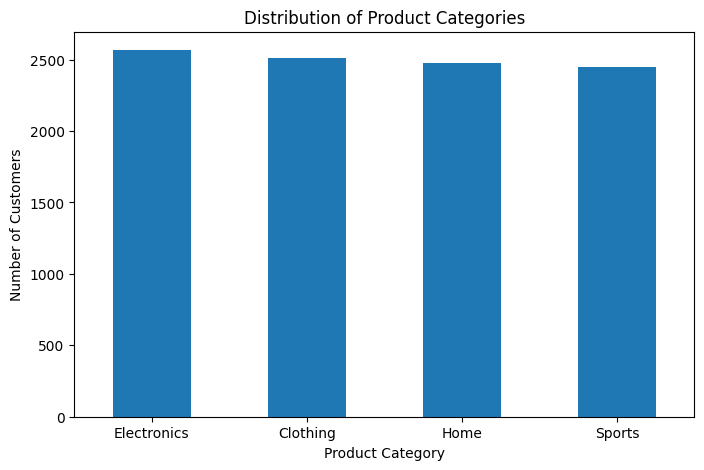

In [ ]:
plt.figure(figsize=(8,5))
df["Most_Frequent_Category"].value_counts().plot(
    kind="bar"
)
plt.title("Distribution of Product Categories")
plt.xlabel("Product Category")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

In [ ]:
category_analysis = df.groupby(
    "Most_Frequent_Category"
)["Average_Order_Value"].mean()
category_analysis

,Average_Order_Value
Most_Frequent_Category,
Clothing,110.600653
Electronics,110.008543
Home,110.543069
Sports,108.850025


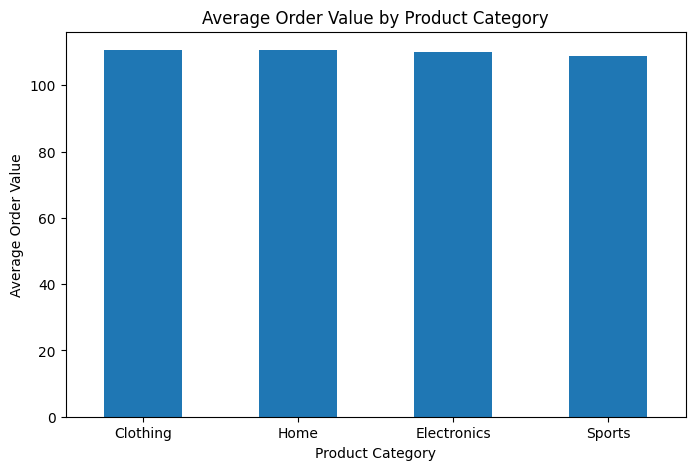

In [ ]:
plt.figure(figsize=(8,5))
category_analysis.sort_values(ascending=False).plot(
    kind="bar"
)
plt.title("Average Order Value by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Order Value")
plt.xticks(rotation=0)
plt.show()

In [ ]:
region_analysis = df.groupby(
    "Region"
)["Average_Order_Value"].mean()
region_analysis

,Average_Order_Value
Region,
Asia,110.213896
Europe,108.942450
North America,110.589063
South America,110.308465


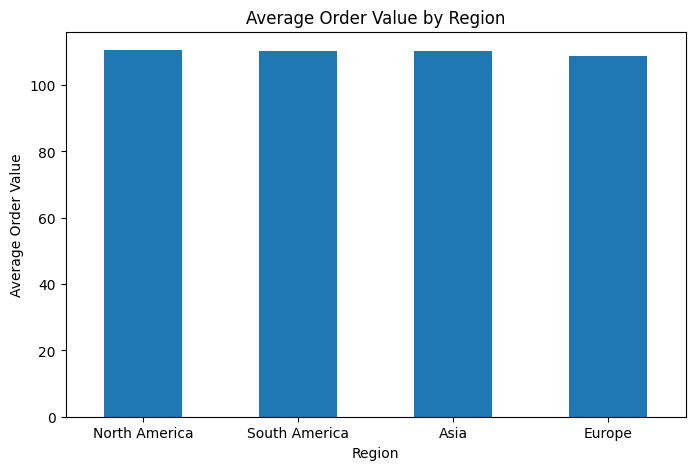

In [ ]:
plt.figure(figsize=(8,5))
region_analysis.sort_values(ascending=False).plot(
    kind="bar"
)
plt.title("Average Order Value by Region")
plt.xlabel("Region")
plt.ylabel("Average Order Value")
plt.xticks(rotation=0)
plt.show()

In [ ]:
region_category = df.groupby(
    ["Region", "Most_Frequent_Category"]
).size()
region_category

Region         Most_Frequent_Category
Asia           Clothing                  635
               Electronics               639
               Home                      599
               Sports                    599
Europe         Clothing                  633
               Electronics               644
               Home                      622
               Sports                    648
North America  Clothing                  601
               Electronics               643
               Home                      633
               Sports                    577
South America  Clothing                  641
               Electronics               641
               Home                      622
               Sports                    623
dtype: int64

In [ ]:
region_category_aov = df.groupby(
    ["Region", "Most_Frequent_Category"]
)["Average_Order_Value"].mean()
region_category_aov

Region         Most_Frequent_Category
Asia           Clothing                  111.483858
               Electronics               108.719812
               Home                      113.248915
               Sports                    107.426444
Europe         Clothing                  109.949510
               Electronics               111.047873
               Home                      108.338248
               Sports                    106.446235
North America  Clothing                  109.581148
               Electronics               109.791524
               Home                      110.400000
               Sports                    112.735078
South America  Clothing                  111.324618
               Electronics               110.466755
               Home                      110.287701
               Sports                    109.120819
Name: Average_Order_Value, dtype: float64

In [ ]:
cross_tab = pd.crosstab(
    df["Region"],
    df["Most_Frequent_Category"]
)
cross_tab

Most_Frequent_Category,Clothing,Electronics,Home,Sports
Region,,,,
Asia,635,639,599,599
Europe,633,644,622,648
North America,601,643,633,577
South America,641,641,622,623


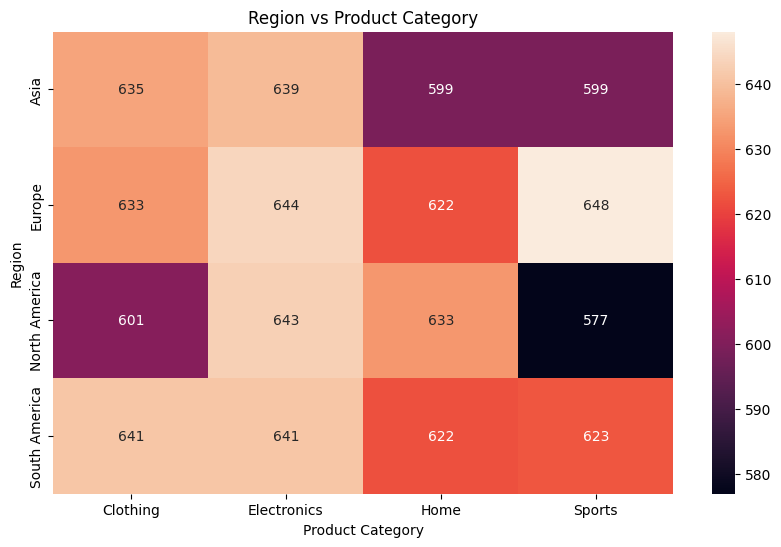

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap( cross_tab,annot=True,fmt="d",)
plt.title("Region vs Product Category")
plt.xlabel("Product Category")
plt.ylabel("Region")
plt.show()

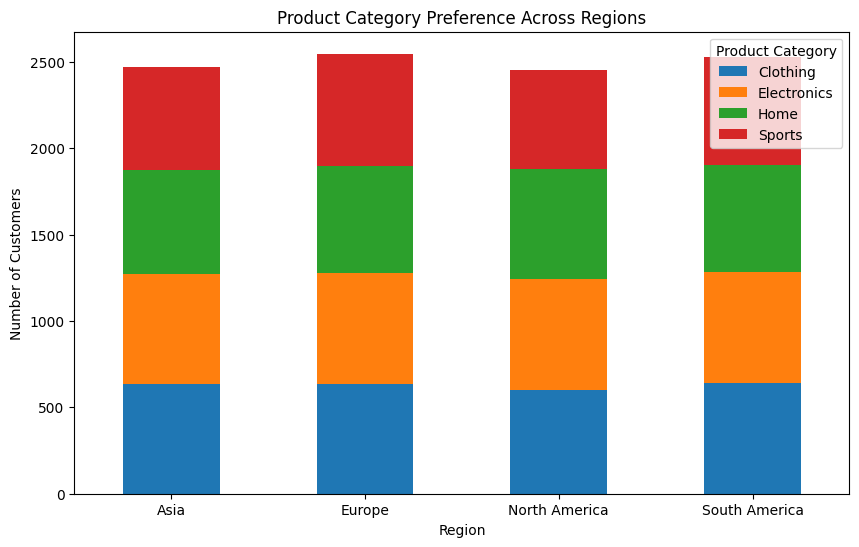

In [ ]:
cross_tab.plot(kind="bar",stacked=True,figsize=(10,6))
plt.title("Product Category Preference Across Regions")
plt.xlabel("Region")
plt.ylabel("Number of Customers")
plt.legend(title="Product Category")
plt.xticks(rotation=0)
plt.show()

In [ ]:
purchase_time = df["Preferred_Purchase_Times"].value_counts()
purchase_time

,count
Preferred_Purchase_Times,
Evening,3433
Afternoon,3354
Morning,3213


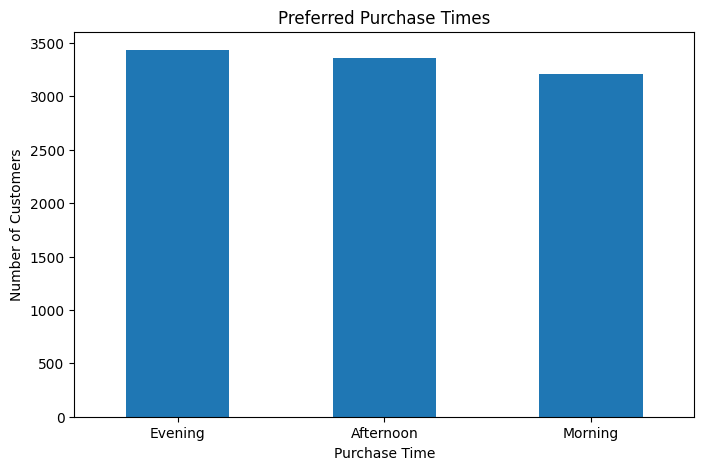

In [ ]:
plt.figure(figsize=(8,5))
purchase_time.plot(kind="bar")
plt.title("Preferred Purchase Times")
plt.xlabel("Purchase Time")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

In [ ]:
region_time = pd.crosstab(
    df["Region"],
    df["Preferred_Purchase_Times"]
)
region_time

Preferred_Purchase_Times,Afternoon,Evening,Morning
Region,,,
Asia,847,824,801
Europe,823,882,842
North America,810,869,775
South America,874,858,795


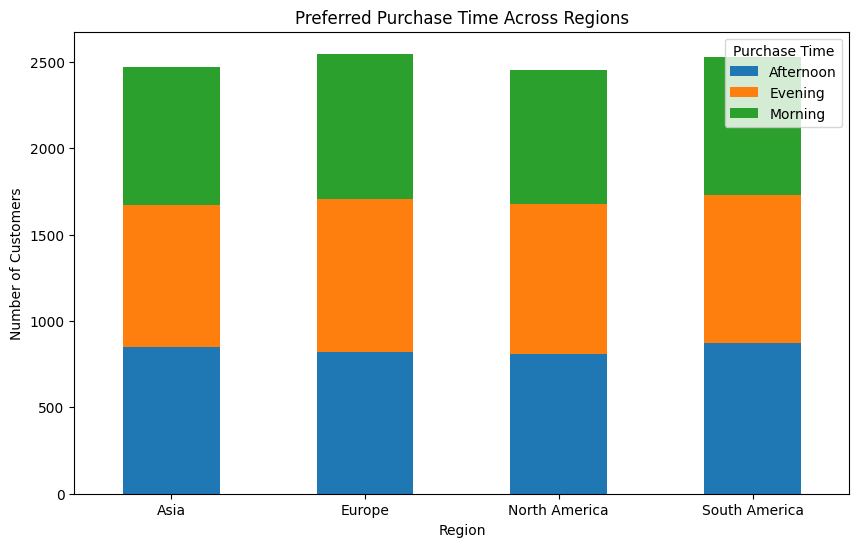

In [ ]:
region_time.plot(kind="bar",stacked=True,figsize=(10,6))
plt.title("Preferred Purchase Time Across Regions")
plt.xlabel("Region")
plt.ylabel("Number of Customers")
plt.legend(title="Purchase Time")
plt.xticks(rotation=0)
plt.show()

In [ ]:
df["Retention_Strategy"].value_counts()

,count
Retention_Strategy,
Loyalty Program,3364
Email Campaign,3359
Discount,3277


In [ ]:
retention_analysis = df.groupby(
    "Retention_Strategy"
)["Churn_Probability"].mean()
retention_analysis

,Churn_Probability
Retention_Strategy,
Discount,0.502926
Email Campaign,0.508348
Loyalty Program,0.493427


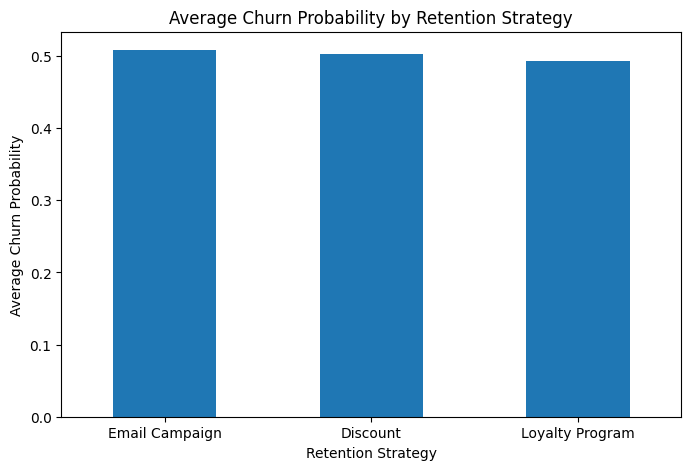

In [ ]:
plt.figure(figsize=(8,5))
retention_analysis.sort_values(ascending=False).plot(kind="bar")
plt.title("Average Churn Probability by Retention Strategy")
plt.xlabel("Retention Strategy")
plt.ylabel("Average Churn Probability")
plt.xticks(rotation=0)
plt.show()

In [ ]:
region_retention = pd.crosstab(df["Region"],df["Retention_Strategy"])
region_retention

Retention_Strategy,Discount,Email Campaign,Loyalty Program
Region,,,
Asia,784,858,830
Europe,857,811,879
North America,807,852,795
South America,829,838,860


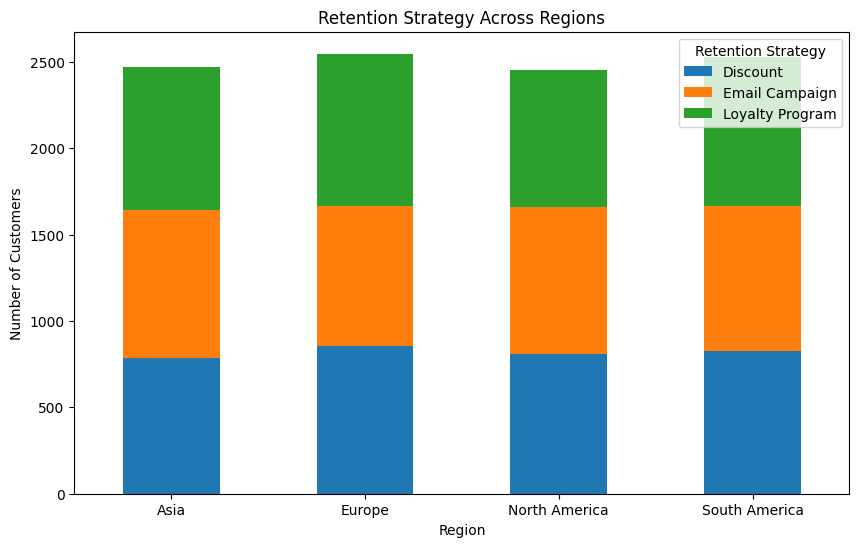

In [ ]:
region_retention.plot(kind="bar",stacked=True,figsize=(10,6))
plt.title("Retention Strategy Across Regions")
plt.xlabel("Region")
plt.ylabel("Number of Customers")
plt.legend(title="Retention Strategy")
plt.xticks(rotation=0)
plt.show()

In [ ]:
main_analysis = pd.crosstab(df["Region"],df["Most_Frequent_Category"])
main_analysis

Most_Frequent_Category,Clothing,Electronics,Home,Sports
Region,,,,
Asia,635,639,599,599
Europe,633,644,622,648
North America,601,643,633,577
South America,641,641,622,623


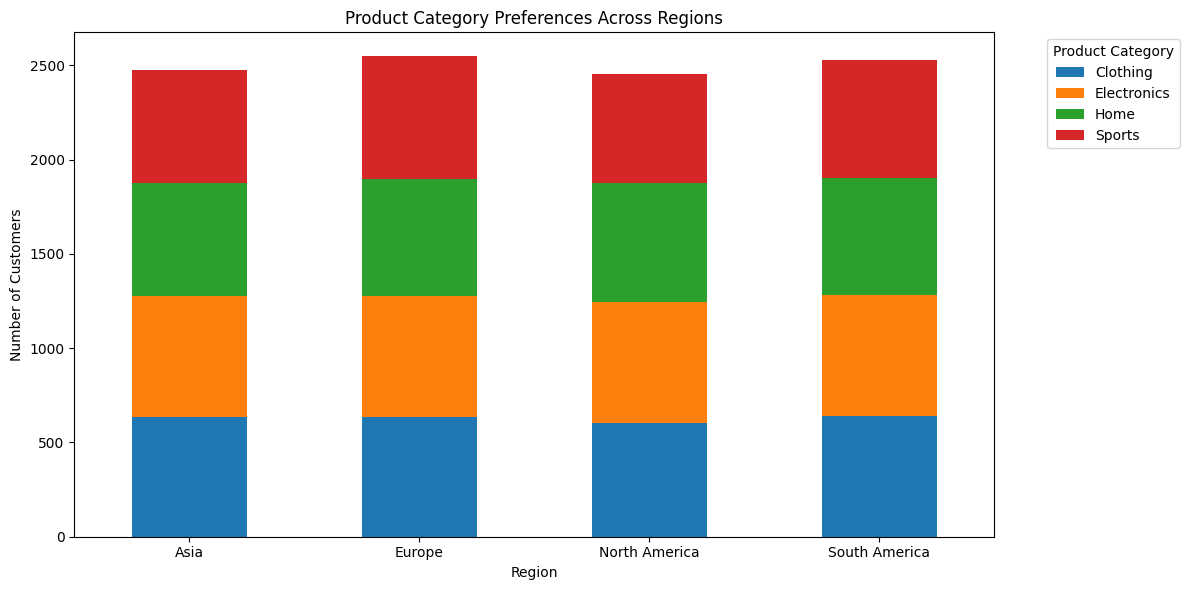

In [ ]:
main_analysis.plot(kind="bar",stacked=True,figsize=(12,6))
plt.title("Product Category Preferences Across Regions")
plt.xlabel("Region")
plt.ylabel("Number of Customers")
plt.legend(title="Product Category",bbox_to_anchor=(1.05, 1),loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()